In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import OneHotEncoder
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

# Data Loading and Understanding

In [2]:
df=pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape

(2240, 22)

In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

In [6]:
# handle missing values 

df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
# Feature Engineering - new feature ko creat kro and purane ko drop kro 

# clustering algorithm dates data ko utne ache se interpret ni kar pati 

# handle dates - jaise hmare data mai year_birth hai good to have but age jada acha feature hoga to know kis age ke logo ko konsi marketing strategies shi rhegi kis age ke logo ko kya psnd ara or vo kya khreedna chate hai
df["Age"]=2026-df["Year_Birth"]

# handle dates - jaise date_of_customer_joining ko convert kar skte hai customer tenure days jo ki platform ko join kia customers ko kitne din ho gye hai jiske lia ham jo sbse last date hogi max date value customer joining ki ussse compare krenge 
# mtlb sari dates ko reference date se minus kar denge jaise age ke lia kia tha but yha date ka dusra format hai (date,month,year) but pandas accept krta hai (month,day,year)
# pandas ke datetime data type mai isliye convert kra kyunki date may be string ho skti hai but pandas ke date time format mai convert karne se ye smj jyega ki date kya hai month kya hai or year jisse dates ke bich subtration ya operation ho skte hai
# String → datetime conversion isliye kiya taaki dates par mathematical/date operations perform kar saken.
# dayFirst=True - Pandas ko batata hai: "Pehla number day hai." kyunki pandas month day year is format mai read krta hai to usa bta denge ham ki first vala month nhi hai day hai
# reference_date = 20-12-2014 , customer_date = 10-01-2012  and reference_date - customer_date = 1075 days but Lekin internally ye simply integer 1075 nahi hota. Ye hota hai: Timedelta('1075 days')
# Phir .dt.days kya karta hai? Agar result hai: Timedelta('1075 days') aur hume sirf number chahiye: 1075
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

# Spending - platform ke andr jitne bhi product hai jaise wines, fruits, meat, fish, sweet, gold to un sb ka sum mtlb total kitna spend kar rhe hai customers on all the products
df["Total_Spending"]= df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

# similarly data mai teenager ka no and kida ka no to ham ek total children nikal skte hai
df["Total_Children"]=df['Kidhome']+df['Teenhome']

In [9]:
df["Education"].value_counts()
# for education we keep categories only - undergraduate(2n cycle, basic), graduate(graduation), postgraducate(phd,master)
df["Education"]=df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "PhD": "Postgraduate",
    "Master": "Postgraduate",
})

df["Marital_Status"].value_counts()
# marital status we keep create a new feature living with mtlb ki kisi ke sath rhre hai ya akele
df["Living_With"]=df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [10]:
# drop unnecessary columns

cols=['ID','Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer']
spending_cols=['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
cols_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=cols_to_drop)
df_cleaned.shape

(2240, 15)

In [11]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Detecting and Removing Outliers

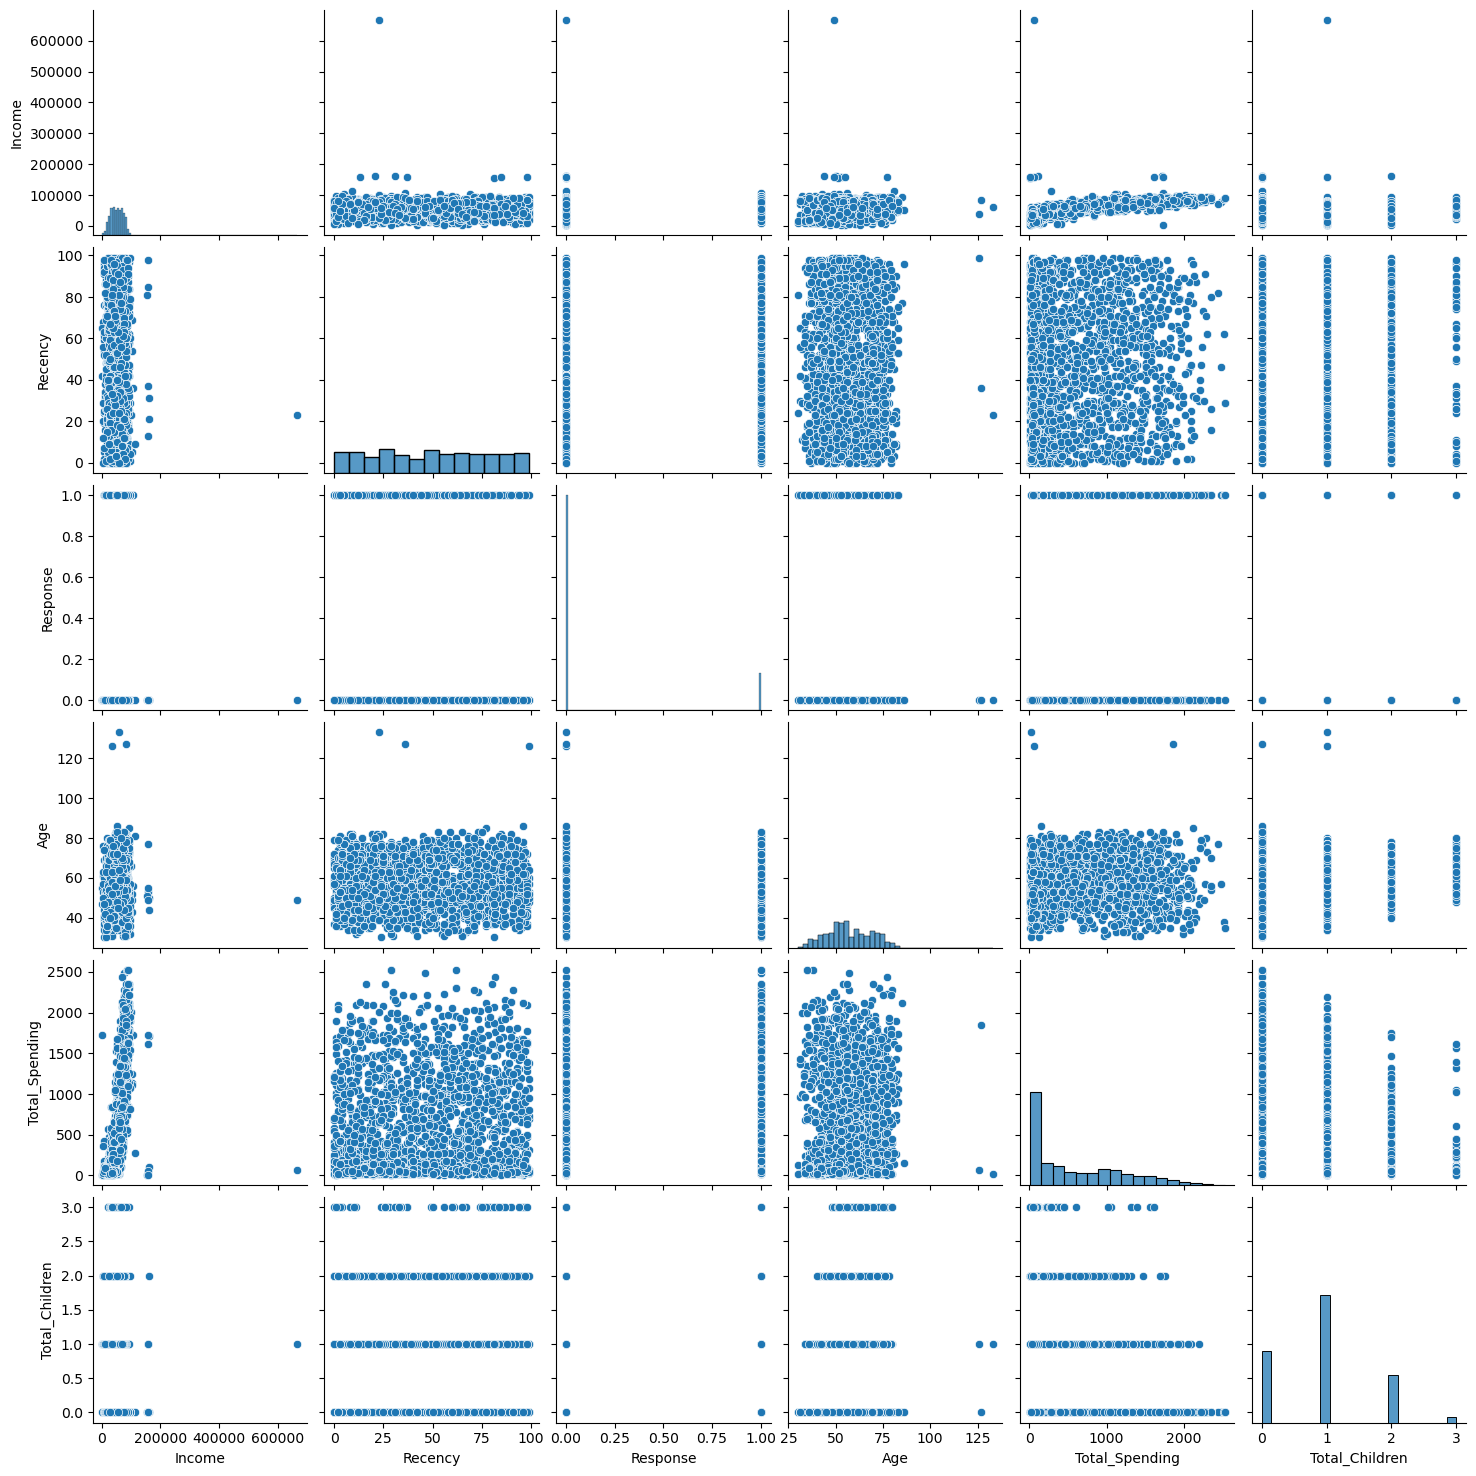

In [12]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [13]:
# outlier to remove - income = around 600000, age= keep <90 and remove >90
print("data size with outliers:",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size without outliers:",len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Check Correlation of features - Heatmaps

In [14]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

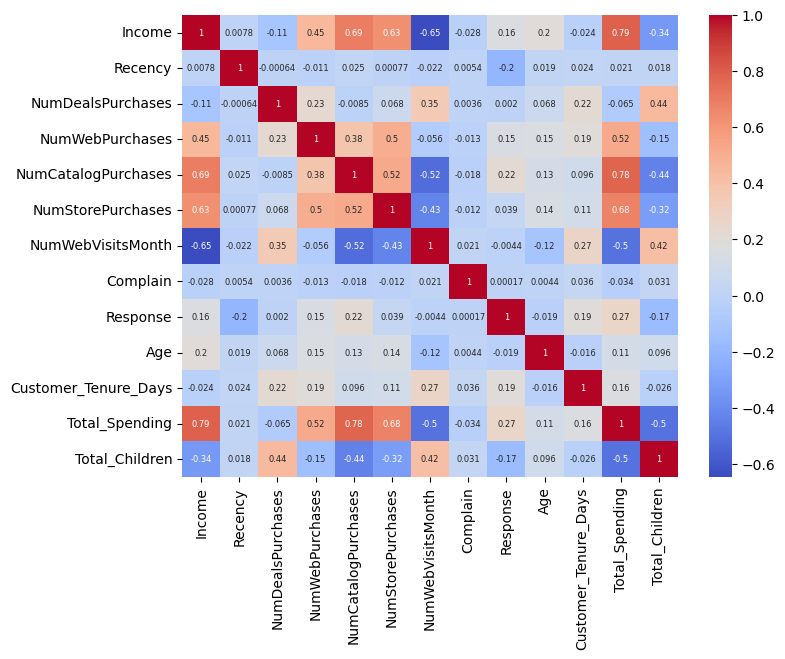

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm",annot_kws={'size':6})

# Encoding

In [16]:
# unsupervised learning mai drop_first=True krne ki jrurat ni hai bcz the problem of multicoliniarity hme clustering ke andr dekhne ko nhi milti, agar kar dia to shyd important data drop hoje 
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
encoded_cols=ohe.fit_transform(df_cleaned[cat_cols])
enc_df=pd.DataFrame(encoded_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


# Scailing

In [17]:
X=df_encoded
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled.shape

(2236, 18)

# Visualize

[0.23163158 0.11385454]


<Axes: >

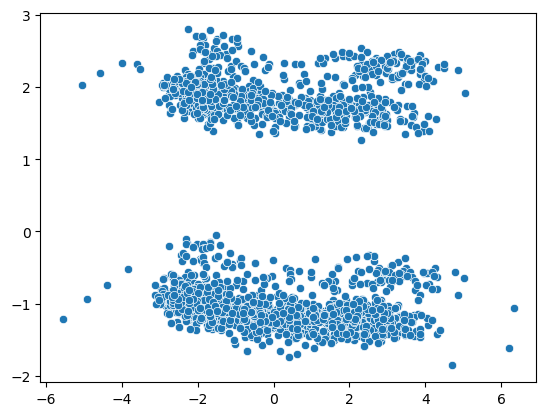

In [18]:
# 2D
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
# bhot kam ratio capture kar rha hai variance capture kar rha hai 2 dimention mai to ham jada dimention lenge 
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1])

[0.23163158 0.11385454 0.10405815]


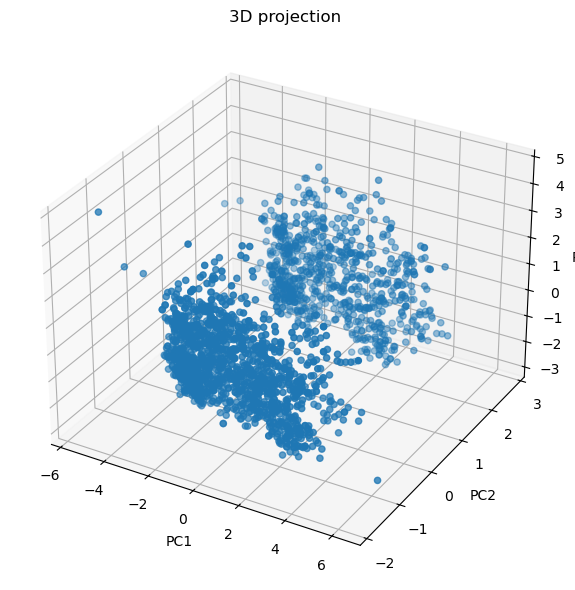

In [19]:
# 3D
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D projection")
fig.tight_layout()

# fig → poori figure/canvas
# add_subplot() → figure ke andar plotting area banana
# 111 → 1 row, 1 column, 1st plot
# (matlab ek hi plot hai)
# projection="3d" → plot ko 3D banana
# ax → is 3D plot ko control karne ke liye variable

# Analyze K value

Best k: 4


Text(0, 0.5, 'WCSS')

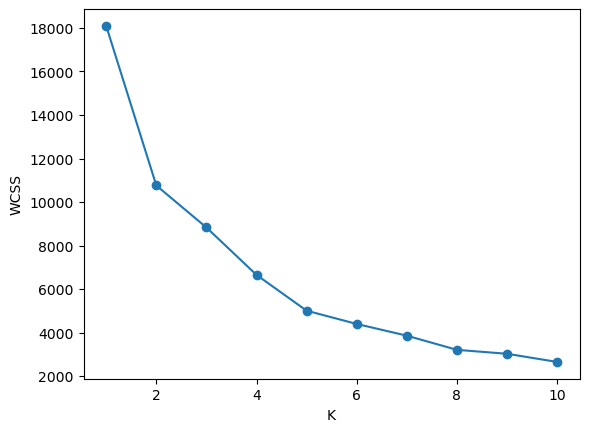

In [20]:
# elbow method

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow
print("Best k:",optimal_k)
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

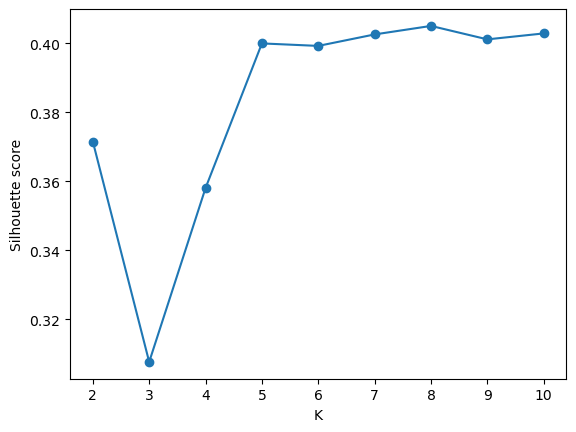

In [21]:
# silhouette score

scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca,labels))
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

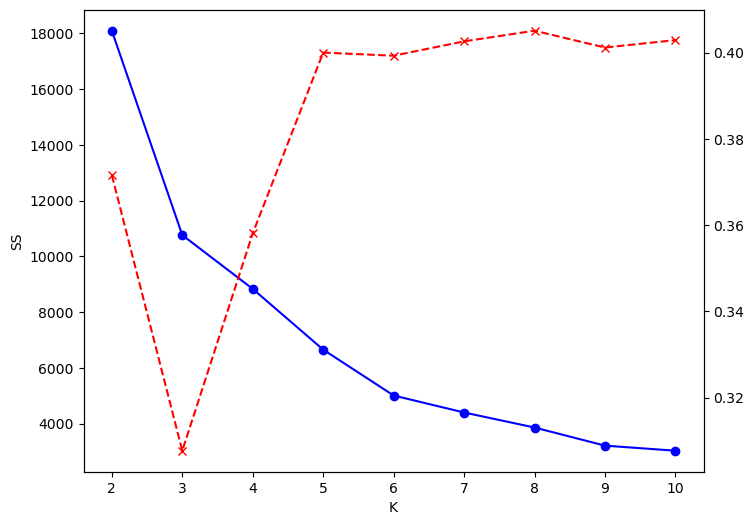

In [22]:
# hme dikhra hoga elbow method and silhouette score hme alg alg value dera hai but generally hm kya kr skte hai ki wcss and silhouette score ka graph plot kr skte hai or jha pa b dono meet kar rhe hai uske arount ki k value lete hai
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color='blue')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color='red',linestyle="--")
ax1.set_ylabel("SS")

# Clustering

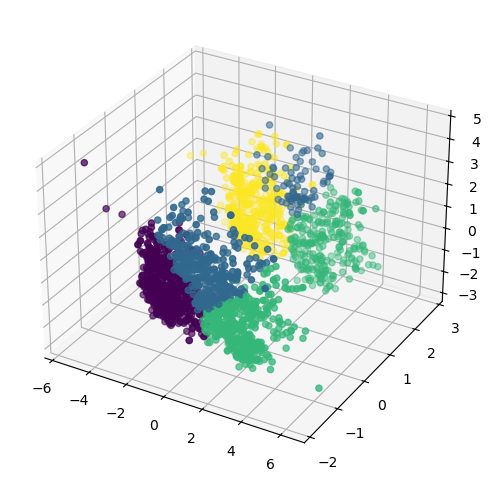

In [23]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

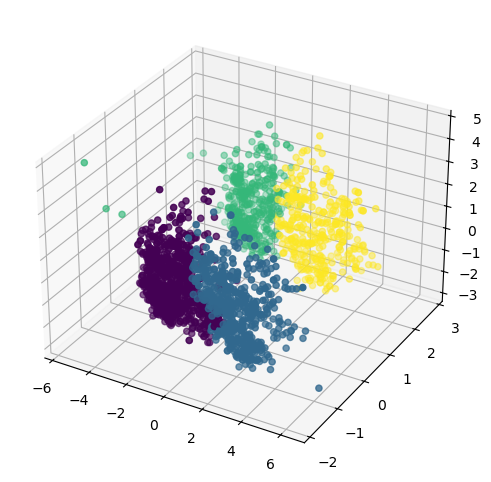

In [24]:
agg=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [25]:
#agglomerative performs better

# Characterization of Clusters

In [31]:
X["Cluster"]=labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Cluster', ylabel='count'>

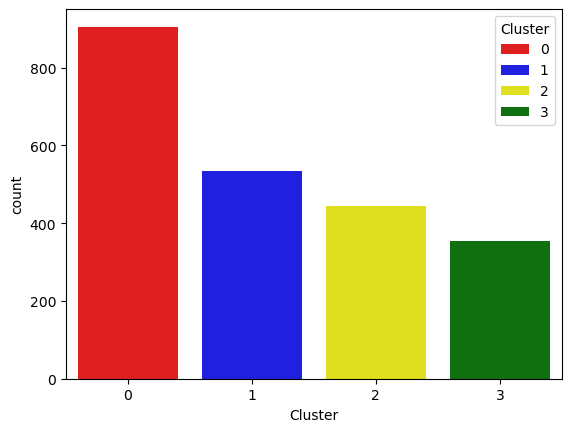

In [32]:
# no. of customers in each clusters 
pal=["red","blue","yellow","green"]
sns.countplot(x=X["Cluster"],palette=pal,hue=X["Cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

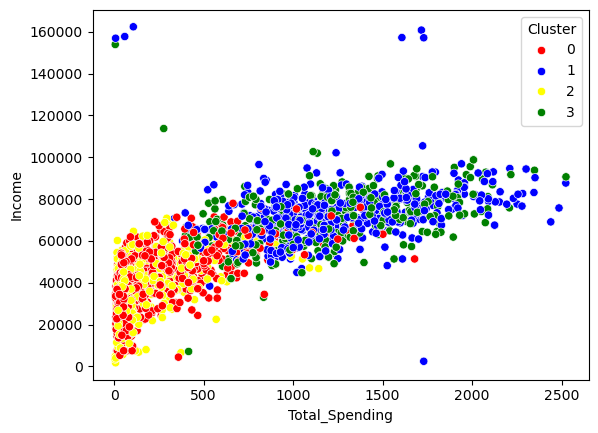

In [33]:
# in correlation heatmap we saw the highest correlation in income and total spending 
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["Cluster"],palette=pal)

#in graph we observe characterstics like
#cluster 0 - (red) either low or moderate income and spending
#cluster 1 - (blue) high income and spending
#cluster 2 - (yellow) low income and spending
#cluster 3 - (green) moderate-high income and high spending

In [35]:
# cluster summary
cluster_summary=X.groupby("Cluster").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
Cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


In [ ]:
# ab ham 4ro clusters se kuch common patterns identify krenge 

# hmne ye dekha ki cluster 1 and cluster 3 ki 
# high spending hai mtlb vo premium customer hai 
# less children
# slightly higher age
# 3: best response, 1:average response
# 3: alone, 1:partner
# web visit low (can target them to visit the website more)
# high web, store and catalog purchase

# cluster 0 and cluster 2 ki 
# low spending hai mtlb vo price sensitive customer hai 
# more children
# slightly lower age
# 2:average response, 0:poor response
# 2:alone, 0:partner
# web visit high
# low web, store and catalog purchase



# cluster 0 - family shoppers - can offer discount coupons
# cluster 1 - average response - can offer loyalty programs (jitne buy kroge utne benefit milenge brand se)
# cluster 2 - digital browsers - can offer sales (heavy discounts, coupons)
# cluster 3 - golden people (best response) high value singles - can offer premium/personalized/one-on-one services